In [45]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
load_dotenv()

from langchain.tools import tool
from langchain_core.tools import Tool


llm = ChatGoogleGenerativeAI(
    model="gemini-flash-lite-latest",
    temperature=0.7,
    google_api_key=os.environ["GOOFLE_API_KEY"]
)

In [46]:
from langchain_community.tools import DuckDuckGoSearchRun

@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)

In [47]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

@tool
def arxiv_tool(query: str) -> str:

    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)

In [48]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

In [49]:
@tool
def personal_info(name: str):

    """Use this tool to get personal information about Alice, Bob, or Charlie. 
    """

    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person.")

In [50]:
tools = [search_duckduckgo, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = llm.bind_tools(tools)

In [51]:
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict,List

class graph_schema(TypedDict):
    messages : List

    


In [52]:
def llm_node(state : graph_schema) -> graph_schema:
    messages = state["messages"]

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", " You are helpful ai assistant tool that gives answers"),
            ("human","{input}")
        ]
    )

    chain = prompt|llm_with_tools
    response = chain.invoke({"input":messages})
    state["messages"] = messages +[response]
    return state

In [53]:
# from langgraph.prebuilt import ToolNode
def tool_node(state: graph_schema) -> graph_schema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state

In [54]:
response = llm_with_tools.invoke("What is the latest news on AI?")
response.tool_calls

[{'name': 'search_duckduckgo',
  'args': {'query': 'latest news on AI October 2024'},
  'id': 'c9984629-5466-4c98-a339-15a824f60d8e',
  'type': 'tool_call'}]

In [55]:
def if_tool_call(state: graph_schema) -> str:

    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

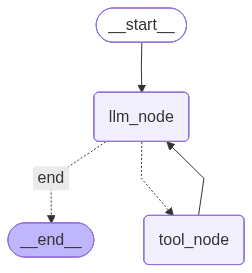

In [56]:

from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

# Add edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call,{"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)


react_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(react_graph.get_graph().draw_mermaid_png())

In [58]:
from langchain_core.messages import HumanMessage, ToolMessage
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "latest news on AI artificial intelligence"}'}, '__gemini_function_call_thought_signatures__': {'b8a6270c-29d3-4c6a-8de9-f39b44580bc9': 'EjQKMgEMOdbHBEEfDB/oMeJN/XBW7FJF3OQd6hw8ElhoPtu/r7Fvmvg4qkEFBudmHazTb+UB'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dfc75-4e85-7162-b283-092224dcba72-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI artificial intelligence'}, 'id': 'b8a6270c-29d3-4c6a-8de9-f39b44580bc9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 245, 'output_tokens': 23, 'total_tokens': 268, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='Explore the w